# Cas de tests - RBF

In [51]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'python')))

from rbf import lib, entrainer_rbf, predire_rbf

In [52]:
COULEURS = ['blue', 'red', 'green']

def precision(predict_fn, X, Y):
    return 100 * sum(predict_fn(x) == y for x, y in zip(X, Y)) / len(X)

def frontiere(predict_fn, X, Y, titre):
    X = np.array(X, dtype=float)
    n = max(Y) + 1
    cmap = ListedColormap(COULEURS[:n])

    pas = 0.05
    vx = np.arange(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, pas)
    vy = np.arange(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, pas)
    Z = [[predict_fn([x, y]) for x in vx] for y in vy]
    plt.contourf(vx, vy, Z, levels=np.arange(-0.5, n), cmap=cmap, alpha=0.15)

    for classe in range(n):
        pts = X[[y == classe for y in Y]]
        plt.scatter(pts[:, 0], pts[:, 1], color=COULEURS[classe])
    plt.title(titre)
    plt.show()

In [53]:
def test_binaire(X, Y_signe, nb, n_centres, gamma):
    Y_lab = [0 if y == 1 else 1 for y in Y_signe]  # 0 = classe "1" (bleu), 1 = classe "-1" (rouge)

    model = entrainer_rbf(X, Y_lab, n_centres, gamma)
    predict_rbf_fn = lambda p: predire_rbf(model, p)
    frontiere(predict_rbf_fn, X, Y_lab, f"RBF - Cas {nb} ({precision(predict_rbf_fn, X, Y_lab):.0f}%)")
    lib.destroy_rbf_model(model)


def test_multiclasse(X, Y, nb, n_centres, gamma):
    Y_lab = [int(np.argmax(y)) for y in Y]

    model = entrainer_rbf(X, Y_lab, n_centres, gamma)
    predict_rbf_fn = lambda p: predire_rbf(model, p)
    frontiere(predict_rbf_fn, X, Y_lab, f"RBF - Cas {nb} ({precision(predict_rbf_fn, X, Y_lab):.0f}%)")
    lib.destroy_rbf_model(model)

## Classification

### Cas 1 : Linear Simple -- attendu OK

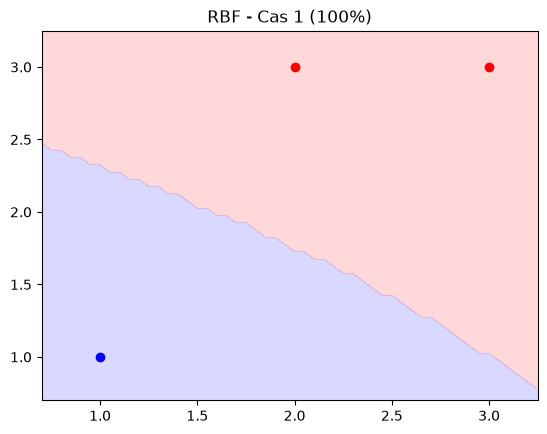

In [54]:
X = [[1, 1], [2, 3], [3, 3]]
Y = [1, -1, -1]
test_binaire(X, Y, nb=1, n_centres=3, gamma=1.0)

### Cas 2 : Linear Multiple -- attendu OK

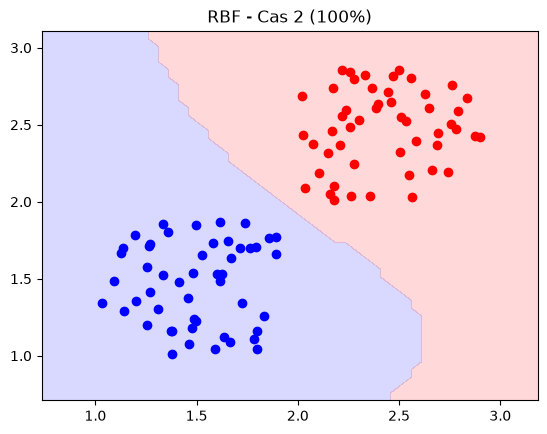

In [55]:
X = np.concatenate([
    np.random.random((50, 2)) * 0.9 + np.array([1, 1]),
    np.random.random((50, 2)) * 0.9 + np.array([2, 2]),
]).tolist()
Y = (np.concatenate([np.ones((50,)), np.ones((50,)) * -1.0])).tolist()
test_binaire(X, Y, nb=2, n_centres=10, gamma=1.0)

### Cas 3 : XOR -- attendu OK (non lineairement separable)

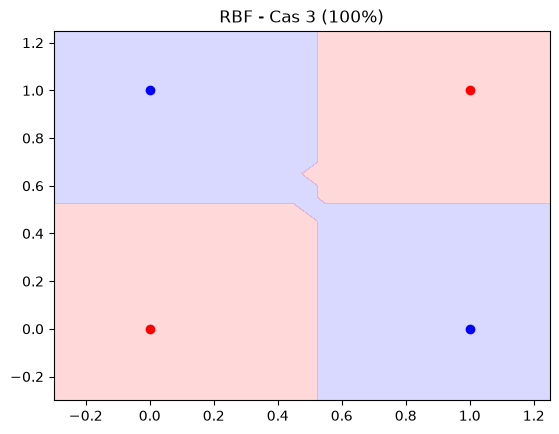

In [56]:
X = [[1, 0], [0, 1], [0, 0], [1, 1]]
Y = [1, 1, -1, -1]
test_binaire(X, Y, nb=3, n_centres=4, gamma=2.0)

### Cas 4 : Cross -- attendu OK

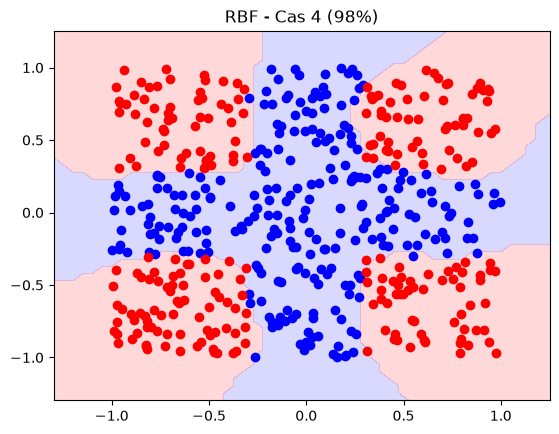

In [57]:
X = (np.random.random((500, 2)) * 2.0 - 1.0).tolist()
Y = [1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X]
test_binaire(X, Y, nb=4, n_centres=50, gamma=2.0)

### Cas 5 : Multi Linear 3 classes -- attendu OK

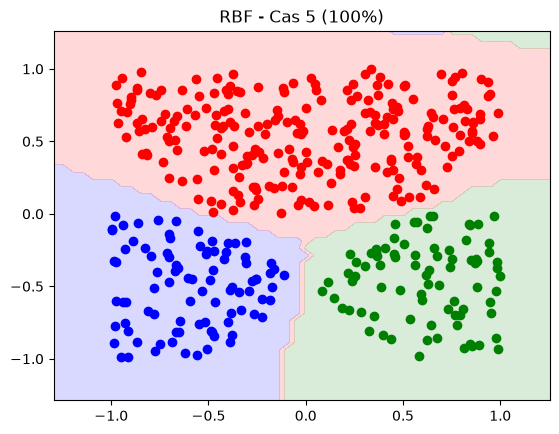

In [58]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([
    [1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
    [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
    [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
    [-1, -1, -1]
    for p in X
])
garde = [not np.all(arr == [-1, -1, -1]) for arr in Y]
X, Y = X[garde].tolist(), Y[garde].tolist()
test_multiclasse(X, Y, nb=5, n_centres=30, gamma=2.0)

### Cas 6 : Multi Cross -- attendu OK

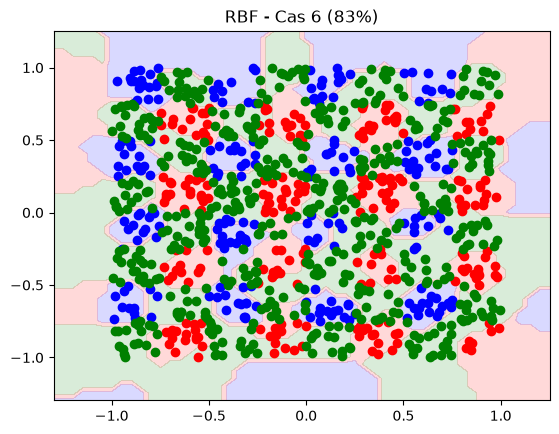

In [59]:
X = (np.random.random((1000, 2)) * 2.0 - 1.0).tolist()
Y = [
    [1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else
    [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else
    [-1, -1, 1]
    for p in X
]
test_multiclasse(X, Y, nb=6, n_centres=100, gamma=5.0)

## Effet de gamma

gamma regle la largeur des bosses. Sur un dataset "cercle" (classe 0 pres du
centre, classe 1 sur l'anneau exterieur) :
- gamma trop petit -> bosses tres larges -> le modele ne discrimine rien (sous-apprentissage)
- gamma bien choisi -> les bosses suivent la forme de l'anneau
- gamma trop grand -> bosses etroites -> le modele colle au bruit (sur-apprentissage)

In [70]:
def generer_cercle(n=200, seed=42):
    rng = np.random.RandomState(seed)
    angles = rng.uniform(0, 2 * np.pi, n)
    n_int = n // 2
    rayons = np.concatenate([
        rng.normal(0.8, 0.25, n_int),        # classe 0 : pres du centre
        rng.normal(1.6, 0.25, n - n_int),    # classe 1 : anneau exterieur
    ])
    labels = np.concatenate([np.zeros(n_int, dtype=int), np.ones(n - n_int, dtype=int)]).tolist()
    X = np.stack([rayons * np.cos(angles), rayons * np.sin(angles)], axis=1).tolist()
    return X, labels

X_cercle, Y_cercle = generer_cercle()

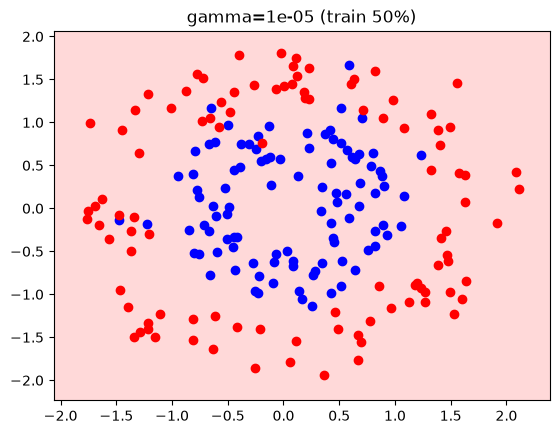

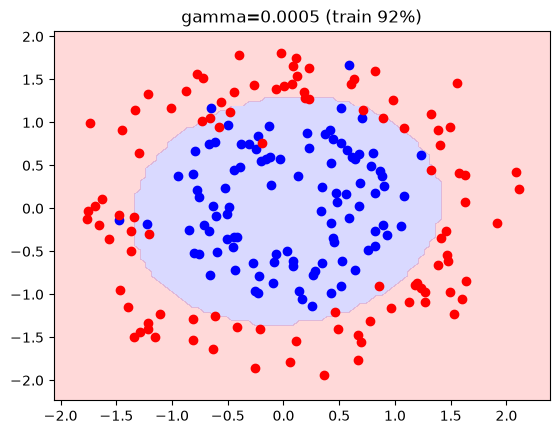

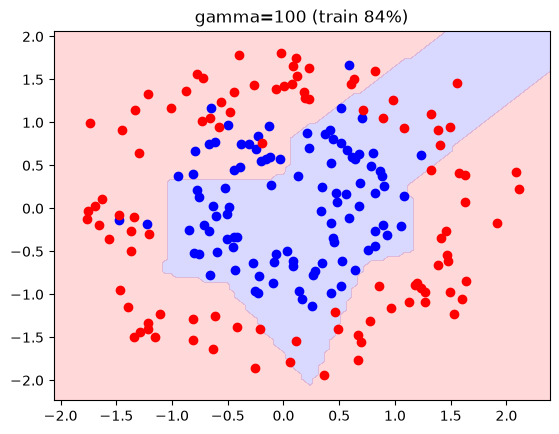

In [71]:
for gamma in [0.00001, 0.0005, 100]:
    model = entrainer_rbf(X_cercle, Y_cercle, n_centres=10, gamma=gamma)
    predict_fn = lambda p: predire_rbf(model, p)
    acc = precision(predict_fn, X_cercle, Y_cercle)
    frontiere(predict_fn, X_cercle, Y_cercle, f"gamma={gamma} (train {acc:.0f}%)")
    lib.destroy_rbf_model(model)